# 01 — Data Inspection

In [1]:
from pathlib import Path
from influence_curriculum.data import DataConfig, load_documents

DATA_DIR = "../datasets/BabyLM-2026-Strict-Small"

/Users/adrian.rojas/dev/babylm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for p in sorted(Path(DATA_DIR).glob("*.txt")):
    lines = p.read_text(errors="replace").splitlines()
    blank_lines = sum(1 for l in lines if not l.strip())
    print(f"{p.name:35s}  total_lines={len(lines):7d}  blank_lines={blank_lines:6d}")
    print("  first 3 non-empty:", [l[:80] for l in lines if l.strip()][:3])
    print()

bnc_spoken.train.txt                 total_lines=  65220  blank_lines=     0
  first 3 non-empty: ["Well it's just that, you know, a pound, or a hundred pounds today, is not the sa", 'Right.', 'So that would be opportunity cost?']

childes.train.txt                    total_lines= 531305  blank_lines=     0
  first 3 non-empty: ['*COL:\tyes your lunch.', '*CHI:\tmore.', '*MOT:\tmore what?']

gutenberg.train.txt                  total_lines=  59934  blank_lines=     0
  first 3 non-empty: ['"My word!" said Bertha.  "I like it.  On’y you tell Bill to cut me stove-wood." ', 'Aileen was still asleep when they reached the farm.  Tom peeped into her room, a', '"Well, I’ll just get things straightened up," said ’Possum, receiving his report']

open_subtitles.train.txt             total_lines= 386046  blank_lines=     0
  first 3 non-empty: ['BUT, JUST AS EXCITING,', 'WE HAVE THE CO-HOSTS OF WAKE UP, SAN FRANCISCO.', "LET'S GIVE IT UP"]

simple_wiki.train.txt                total_lines=  58709

In [3]:
cfg = DataConfig(doc_boundary="line", min_doc_tokens=1)
texts, ids = load_documents(DATA_DIR, cfg)
from collections import Counter
source_counts = Counter(i.split("#")[0] for i in ids)
print(f"Total docs: {len(texts)}")
for src, cnt in sorted(source_counts.items()):
    print(f"  {src:25s}: {cnt:6d} docs")

Total docs: 1104106
  bnc_spoken.train         :  65220 docs
  childes.train            : 531305 docs
  gutenberg.train          :  59934 docs
  open_subtitles.train     : 386046 docs
  simple_wiki.train        :  58709 docs
  switchboard.train        :   2892 docs


In [4]:
import numpy as np
for src in source_counts:
    src_texts = [t for t, i in zip(texts, ids) if i.startswith(src)]
    lengths = [len(t.split()) for t in src_texts]
    print(f"{src:25s}: median={np.median(lengths):.0f} words, max={max(lengths)}")

bnc_spoken.train         : median=7 words, max=298
childes.train            : median=4 words, max=163
gutenberg.train          : median=25 words, max=1033
open_subtitles.train     : median=5 words, max=75
simple_wiki.train        : median=14 words, max=654
switchboard.train        : median=6 words, max=67


## Custom segmentation rules

In [5]:
import re

def segment_childes(text: str) -> list[str]:
    """Strip CHAT speaker prefixes (*SPK:\t) and action annotations ([...]).
    Each non-empty cleaned utterance becomes one document."""
    docs = []
    for line in text.splitlines():
        # Remove action/annotation lines like [leaves room.]
        if re.match(r'^\[', line.strip()):
            continue
        # Strip speaker prefix  *XXX:\t
        line = re.sub(r'^\*[A-Z]+:\t', '', line)
        # Remove inline annotations [...]
        line = re.sub(r'\[.*?\]', '', line).strip()
        if line:
            docs.append(line)
    return docs

# Quick sanity check
sample = "*COL:\tyes your lunch.\n*CHI:\tmore.\n[leaves room.]\n*MOT:\tmore [what?] okay."
print(segment_childes(sample))

['yes your lunch.', 'more.', 'more  okay.']


In [6]:
def segment_simple_wiki(text: str) -> list[str]:
    """Group lines between = = = Title = = = headers into one document per article.
    The header line itself is prepended as the title."""
    docs = []
    current: list[str] = []
    for line in text.splitlines():
        if re.match(r'^= = =', line.strip()):
            if current:
                docs.append(' '.join(current))
            # Start new article with title (stripped of = = = markers)
            title = re.sub(r'= = =', '', line).strip()
            current = [title] if title else []
        elif line.strip():
            current.append(line.strip())
    if current:
        docs.append(' '.join(current))
    return docs

# Quick sanity check
sample = "= = = Bullet the Blue Sky = = =\nSong by U2.\nReleased in 1987.\n= = = Another Song = = =\nAnother article."
print(segment_simple_wiki(sample))

['Bullet the Blue Sky Song by U2. Released in 1987.', 'Another Song Another article.']


In [7]:
# Run with custom rules and compare doc counts
custom_cfg = DataConfig(
    doc_boundary={
        "childes.train.txt": segment_childes,
        "simple_wiki.train.txt": segment_simple_wiki,
    },
    default_boundary="line",
    min_doc_tokens=3,
)

texts_c, ids_c = load_documents(DATA_DIR, custom_cfg)
counts_c = Counter(i.split("#")[0] for i in ids_c)

print(f"{'Source':30s}  {'line':>8s}  {'custom':>8s}  {'change':>8s}")
print("-" * 60)
all_sources = sorted(set(list(source_counts.keys()) + list(counts_c.keys())))
for src in all_sources:
    before = source_counts.get(src, 0)
    after = counts_c.get(src, 0)
    print(f"{src:30s}  {before:8d}  {after:8d}  {after-before:+8d}")
print("-" * 60)
print(f"{'TOTAL':30s}  {len(texts):8d}  {len(texts_c):8d}  {len(texts_c)-len(texts):+8d}")

Source                              line    custom    change
------------------------------------------------------------
bnc_spoken.train                   65220     48831    -16389
childes.train                     531305    302745   -228560
gutenberg.train                    59934     56991     -2943
open_subtitles.train              386046    300588    -85458
simple_wiki.train                  58709     14790    -43919
switchboard.train                   2892      2064      -828
------------------------------------------------------------
TOTAL                            1104106    726009   -378097


In [8]:
# Word-length distribution under custom rules
print(f"{'Source':30s}  {'median_words':>12s}  {'max_words':>10s}")
print("-" * 56)
for src in all_sources:
    src_texts = [t for t, i in zip(texts_c, ids_c) if i.startswith(src)]
    if not src_texts:
        continue
    lengths = [len(t.split()) for t in src_texts]
    print(f"{src:30s}  {np.median(lengths):12.0f}  {max(lengths):10d}")

Source                          median_words   max_words
--------------------------------------------------------
bnc_spoken.train                          10         298
childes.train                              5          97
gutenberg.train                           26        1033
open_subtitles.train                       6          75
simple_wiki.train                         56        7791
switchboard.train                          9          67


In [9]:
# Sample 3 docs from each source to visually confirm quality
import random
rng = random.Random(42)
for src in all_sources:
    src_texts = [t for t, i in zip(texts_c, ids_c) if i.startswith(src)]
    sample = rng.sample(src_texts, min(3, len(src_texts)))
    print(f"\n=== {src} ===")
    for s in sample:
        print(f"  {s[:120]}")


=== bnc_spoken.train ===
  I did work for a petrol company .
  Collect the packaged goods to be transferred from
  Well colleagues, John  er, General Secretary speaking on behalf of the C E C.

=== childes.train ===
  xxx a plate.
  I believe if you leave your tooth in an envelope under your pillow someone will come take the tooth and leave a present 
  is this a elephant?

=== gutenberg.train ===
  "The sea will do him a sight of good, the darling," said Netty, kissing him with rapture.
  "A distant cousin of General Talland's, Mr. George Talland, a most unsuitable man from all accounts. I believe he spends
  "She'll wear it," said Nesta, "and she'll look as pretty as you, Ethel."

=== open_subtitles.train ===
  -patty's boyfriend and she's...
  In New York, we stay up all night... watch the sun come up over the warehouses.
  Can I loosen up now?

=== simple_wiki.train ===
  VIA Iveria VIA Iveria (Georgian: ������, Russian: ��� ������) was a Georgian music band ensemble founded in 19

## Word-count distributions per source

Matplotlib is building the font cache; this may take a moment.


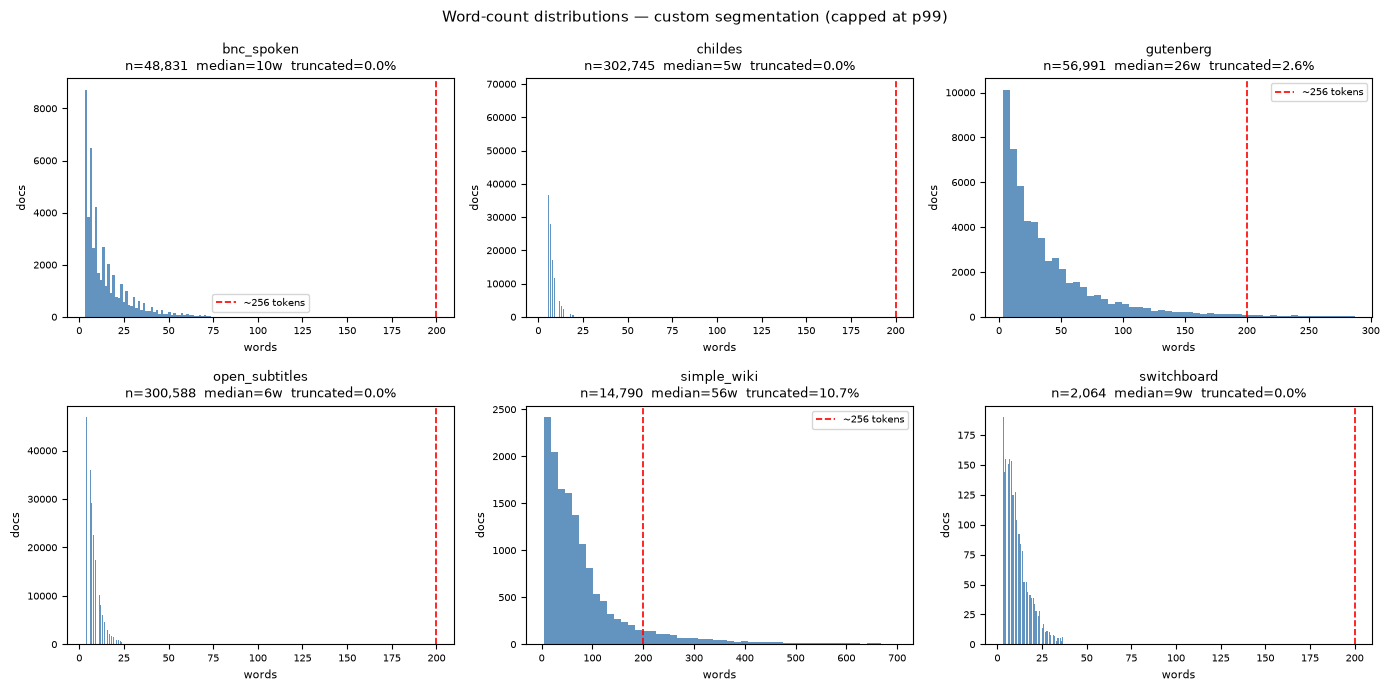

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Build per-source length arrays
lengths_by_src = {}
for src in all_sources:
    src_texts = [t for t, i in zip(texts_c, ids_c) if i.startswith(src)]
    lengths_by_src[src] = np.array([len(t.split()) for t in src_texts])

MAX_SEQ_WORDS = 200  # ~256 tokens (rough 1.28 tokens/word)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, src in zip(axes, all_sources):
    lens = lengths_by_src[src]
    pct_truncated = 100 * (lens > MAX_SEQ_WORDS).mean()
    p99 = int(np.percentile(lens, 99))
    ax.hist(lens[lens <= p99], bins=50, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(MAX_SEQ_WORDS, color='red', linewidth=1.2, linestyle='--', label='~256 tokens')
    ax.set_title(
        f"{src.replace('.train', '')}\n"
        f"n={len(lens):,}  median={np.median(lens):.0f}w  truncated={pct_truncated:.1f}%",
        fontsize=9)
    ax.set_xlabel('words', fontsize=8)
    ax.set_ylabel('docs', fontsize=8)
    ax.tick_params(labelsize=7)
    if pct_truncated > 0:
        ax.legend(fontsize=7)

plt.suptitle('Word-count distributions — custom segmentation (capped at p99)', fontsize=11)
plt.tight_layout()
plt.show()

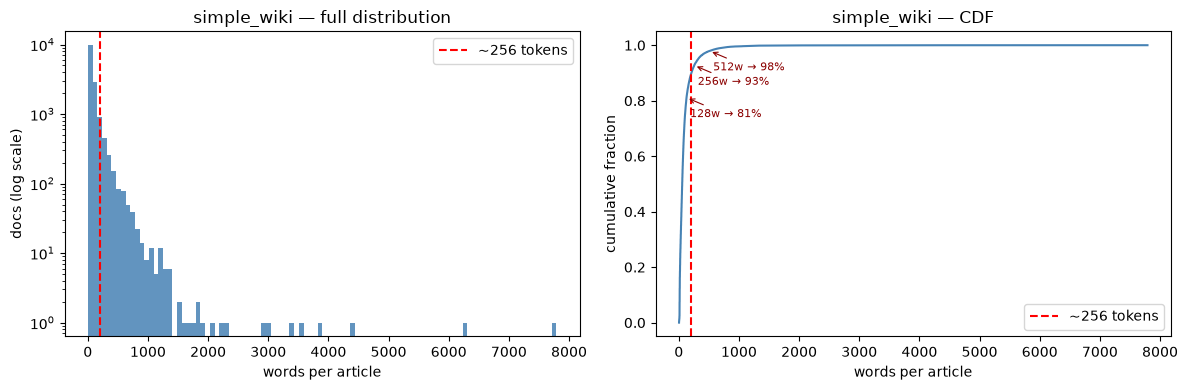

simple_wiki coverage at various word limits:
  <=   50 words: 45.2% of articles
  <=  100 words: 74.0% of articles
  <=  200 words: 89.3% of articles
  <=  256 words: 92.7% of articles
  <=  512 words: 97.9% of articles
  <= 1000 words: 99.6% of articles


In [11]:
# simple_wiki deep-dive: full range + CDF
wiki_lens = lengths_by_src['simple_wiki.train']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution, log y-scale to show the long tail
ax1.hist(wiki_lens, bins=100, color='steelblue', edgecolor='none', alpha=0.85)
ax1.axvline(MAX_SEQ_WORDS, color='red', linewidth=1.5, linestyle='--', label='~256 tokens')
ax1.set_yscale('log')
ax1.set_xlabel('words per article')
ax1.set_ylabel('docs (log scale)')
ax1.set_title('simple_wiki — full distribution')
ax1.legend()

# CDF: what % of articles fit within N words?
sorted_lens = np.sort(wiki_lens)
cdf = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
ax2.plot(sorted_lens, cdf, color='steelblue')
ax2.axvline(MAX_SEQ_WORDS, color='red', linewidth=1.5, linestyle='--', label='~256 tokens')
for thresh, offset in [(128, (60, -0.07)), (256, (60, -0.07)), (512, (60, -0.07))]:
    pct = 100 * (wiki_lens <= thresh).mean()
    ax2.annotate(f'{thresh}w → {pct:.0f}%', xy=(thresh, pct/100),
                 xytext=(thresh + offset[0], pct/100 + offset[1]),
                 fontsize=8, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
ax2.set_xlabel('words per article')
ax2.set_ylabel('cumulative fraction')
ax2.set_title('simple_wiki — CDF')
ax2.legend()

plt.tight_layout()
plt.show()

print("simple_wiki coverage at various word limits:")
for w in [50, 100, 200, 256, 512, 1000]:
    print(f"  <= {w:4d} words: {100*(wiki_lens<=w).mean():.1f}% of articles")